# Hidden Markov Models, from scratch and with Pyro

Years ago I wanted to play with Hidden Markov Models (HMMs) and their relatives for energy disaggregation, but the tooling was painful. Today we can write the *generative story* of a model in a few lines of [Pyro](https://pyro.ai) -- a probabilistic programming language built on PyTorch -- and get exact inference for free. Even better, **changing the graphical model is just editing the story**, which is exactly what we will need when we move from a plain HMM to a *factorial* HMM later in this series.

This first post is deliberately tiny. We use the textbook **rain/sun** example and do everything twice: once with hand-written PyTorch so the math is transparent, and once in Pyro so you can see the pattern we will reuse and vary.

The story: the *weather* each day is hidden from us (`Rainy` or `Sunny`). All we observe is what a friend chooses to do -- `walk`, `shop`, or `clean`. Weather tends to persist from day to day, and it nudges the activity. **From the activities alone, can we recover the weather?**

## The model

An HMM has a chain of hidden states $z_1, z_2, \dots, z_T$ with one observation $x_t$ per state. It is defined by three pieces:

- an **initial** distribution $\pi_i = P(z_1 = i)$,
- a **transition** matrix $A_{ij} = P(z_{t+1}=j \mid z_t=i)$,
- an **emission** matrix $B_{ik} = P(x_t = k \mid z_t = i)$.

The joint probability factorizes along the chain:

$$P(z_{1:T}, x_{1:T}) = \pi_{z_1}\, B_{z_1 x_1} \prod_{t=2}^{T} A_{z_{t-1} z_t}\, B_{z_t x_t}.$$

Two assumptions hide in that product: each state depends only on the previous one (the *Markov* property), and each observation depends only on the current state.

In [1]:
import torch
import pyro
import pyro.distributions as dist
from pyro.ops.indexing import Vindex
from pyro.infer import config_enumerate, TraceEnum_ELBO, infer_discrete
from pyro import poutine

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pyro.set_rng_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

/Users/nipun/git/hmm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
states    = ["Rainy", "Sunny"]          # hidden weather
obs_names = ["walk", "shop", "clean"]   # what we see our friend do

pi = torch.tensor([0.6, 0.4])           # P(weather on day 1)
A  = torch.tensor([[0.7, 0.3],          # P(tomorrow | Rainy today)
                   [0.4, 0.6]])         # P(tomorrow | Sunny today)
B  = torch.tensor([[0.1, 0.4, 0.5],     # P(activity | Rainy)
                   [0.6, 0.3, 0.1]])    # P(activity | Sunny)

print("Transition A  (rows = today, cols = tomorrow):")
display(pd.DataFrame(A.numpy(), index=states, columns=states))
print("\nEmission B  (rows = weather, cols = activity):")
display(pd.DataFrame(B.numpy(), index=states, columns=obs_names))

Transition A  (rows = today, cols = tomorrow):


,Rainy,Sunny
Rainy,0.7,0.3
Sunny,0.4,0.6



Emission B  (rows = weather, cols = activity):


,walk,shop,clean
Rainy,0.1,0.4,0.5
Sunny,0.6,0.3,0.1


Here is the same model as a picture. Shaded top nodes are the hidden weather, bottom nodes are the activities we actually observe; arrows show what depends on what.

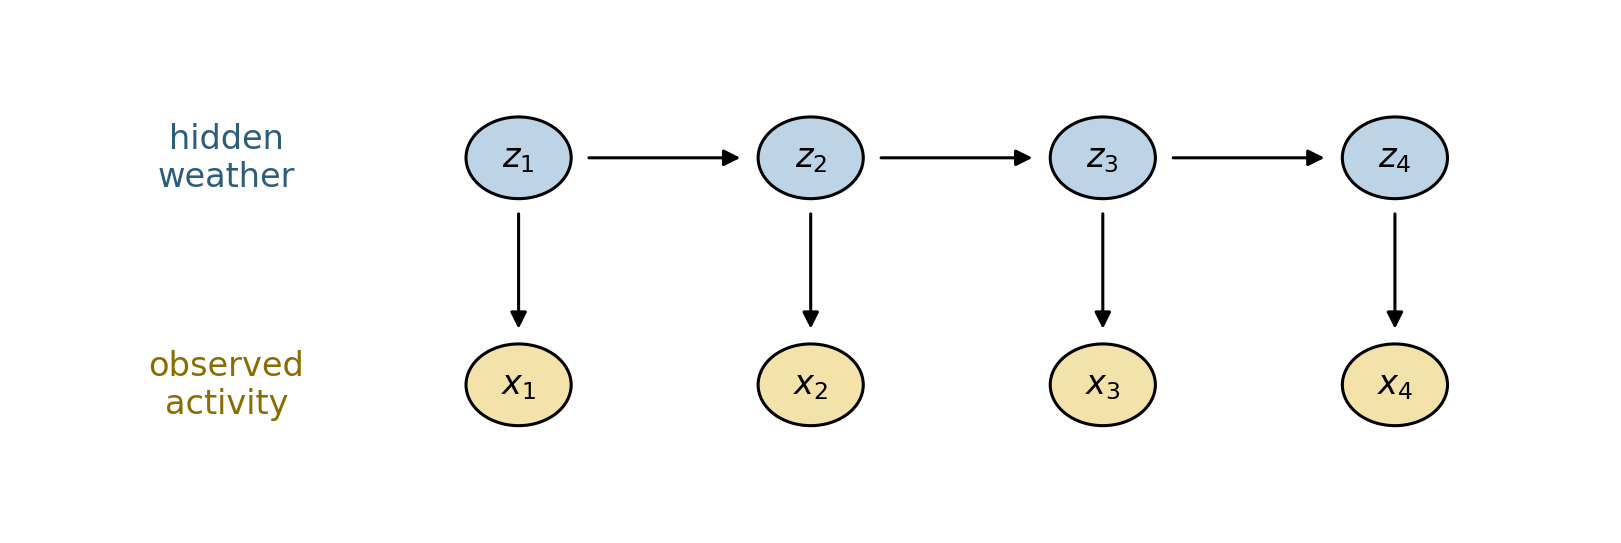

In [3]:
from matplotlib.patches import Circle

def draw_hmm(n=4):
    fig, ax = plt.subplots(figsize=(7.5, 2.6))
    for t in range(n):
        ax.add_patch(Circle((t, 1), 0.18, fc="#bcd4e6", ec="k", zorder=3))   # hidden z
        ax.add_patch(Circle((t, 0), 0.18, fc="#f3e2a9", ec="k", zorder=3))   # observed x
        ax.text(t, 1, f"$z_{{{t+1}}}$", ha="center", va="center", zorder=4)
        ax.text(t, 0, f"$x_{{{t+1}}}$", ha="center", va="center", zorder=4)
        ax.annotate("", xy=(t, 0.22), xytext=(t, 0.78),
                    arrowprops=dict(arrowstyle="-|>", color="k"))            # z -> x
        if t < n - 1:
            ax.annotate("", xy=(t + 0.78, 1), xytext=(t + 0.22, 1),
                        arrowprops=dict(arrowstyle="-|>", color="k"))        # z -> z
    ax.text(-1.0, 1, "hidden\nweather", ha="center", va="center", color="#2c5d7c")
    ax.text(-1.0, 0, "observed\nactivity", ha="center", va="center", color="#8a6d00")
    ax.set_xlim(-1.7, n - 0.3); ax.set_ylim(-0.6, 1.6); ax.axis("off")
    plt.tight_layout(); plt.show()

draw_hmm(4)

## 1. Simulating: ancestral sampling

To sample from an HMM you walk down the chain: draw the first weather from $\pi$, draw an activity from its emission row, then draw the next weather from the transition row, and repeat. This is *ancestral sampling* -- sample each variable after its parents.

In [4]:
def sample_hmm(T, seed=0):
    g = torch.Generator().manual_seed(seed)
    zs, xs = [], []
    z = torch.multinomial(pi, 1, generator=g).item()
    for t in range(T):
        if t > 0:
            z = torch.multinomial(A[z], 1, generator=g).item()
        x = torch.multinomial(B[z], 1, generator=g).item()
        zs.append(z); xs.append(x)
    return zs, xs

T = 14
zs, xs = sample_hmm(T, seed=18)
print("Day      :", " ".join(f"{t+1:>5}" for t in range(T)))
print("Weather  :", " ".join(f"{states[z][:5]:>5}" for z in zs))
print("Activity :", " ".join(f"{obs_names[x][:5]:>5}" for x in xs))

Day      :     1     2     3     4     5     6     7     8     9    10    11    12    13    14
Weather  : Sunny Sunny Sunny Rainy Rainy Sunny Rainy Rainy Rainy Rainy Sunny Sunny Sunny Sunny
Activity :  walk  walk  walk  shop  shop  walk clean  shop  shop  shop  walk  shop  walk  walk


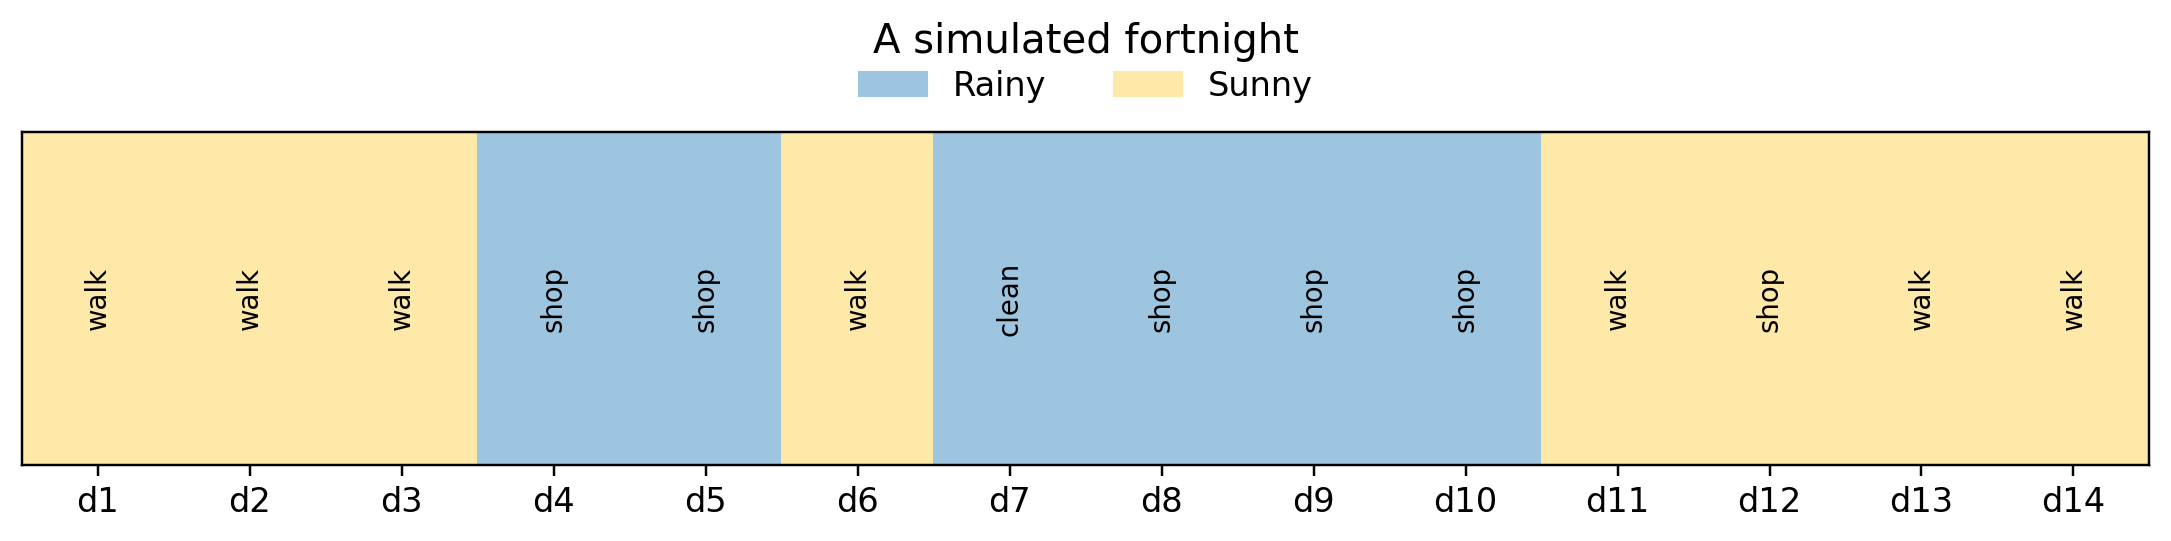

In [5]:
def plot_sequence(zs, xs, title="A simulated fortnight"):
    T = len(zs)
    fig, ax = plt.subplots(figsize=(10, 2.6))
    for t, z in enumerate(zs):
        ax.axvspan(t - 0.5, t + 0.5, color="#9ec5e0" if z == 0 else "#ffe9a8")
    for t, x in enumerate(xs):
        ax.text(t, 0, obs_names[x], rotation=90, ha="center", va="center", fontsize=9)
    ax.set_ylim(-1, 1)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color="#9ec5e0", label="Rainy"),
                       Patch(color="#ffe9a8", label="Sunny")],
              loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.28), frameon=False)
    ax.set_yticks([]); ax.set_xticks(range(T))
    ax.set_xticklabels([f"d{t+1}" for t in range(T)])
    ax.set_xlim(-0.5, T - 0.5); ax.set_title(title, pad=26)
    plt.tight_layout(); plt.show()

plot_sequence(zs, xs)

## The same model in Pyro

In Pyro we don't write the sampler by hand -- we write the *model* as a function where each random choice is a `pyro.sample` statement, and Pyro works out how to sample, score, or do inference on it. A few things to notice:

- `pyro.markov(range(T))` tells Pyro the chain has the Markov property, which keeps inference cheap.
- `infer={"enumerate": "parallel"}` marks the hidden states as discrete variables Pyro can *sum over exactly* -- that is how we get the forward algorithm for free.
- `Vindex(A)[..., z, :]` is safe fancy-indexing that still works when `z` is a whole batch of enumerated values.

Pass `activities=None` and the function *generates* data; pass an observed sequence and the same function *conditions* on it. One model, many uses.

In [6]:
def hmm(activities=None, T=None):
    if activities is not None:
        T = activities.shape[0]
    z = None
    for t in pyro.markov(range(T)):
        if t == 0:
            z = pyro.sample("z_0", dist.Categorical(pi),
                            infer={"enumerate": "parallel"})
        else:
            z = pyro.sample(f"z_{t}", dist.Categorical(Vindex(A)[..., z, :]),
                            infer={"enumerate": "parallel"})
        obs_t = None if activities is None else activities[t]
        pyro.sample(f"x_{t}", dist.Categorical(Vindex(B)[..., z, :]), obs=obs_t)
    return z

# generate one sequence from the Pyro model (activities=None -> sampling mode)
pyro.set_rng_seed(3)
tr = poutine.trace(hmm).get_trace(T=14)
zs_p = [int(tr.nodes[f"z_{t}"]["value"]) for t in range(14)]
xs_p = [int(tr.nodes[f"x_{t}"]["value"]) for t in range(14)]
print("Weather  :", [states[z] for z in zs_p])
print("Activity :", [obs_names[x] for x in xs_p])

Weather  : ['Rainy', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Sunny']
Activity : ['shop', 'walk', 'shop', 'clean', 'walk', 'shop', 'walk', 'walk', 'walk', 'clean', 'clean', 'walk', 'walk', 'clean']


## 2. Scoring a sequence: the forward algorithm

How probable is an observed sequence of activities, summing over *every* possible weather history? Naively that is $2^T$ paths. The **forward algorithm** does it in $O(T)$ by carrying forward $\alpha_t(i) = P(x_{1:t}, z_t = i)$:

$$\alpha_1(i) = \pi_i\, B_{i x_1}, \qquad \alpha_{t}(j) = \Big(\textstyle\sum_i \alpha_{t-1}(i)\, A_{ij}\Big)\, B_{j x_t},$$

and $P(x_{1:T}) = \sum_i \alpha_T(i)$. We work in log-space for numerical stability.

In [7]:
obs = torch.tensor(xs)   # the activities we saw earlier; weather is hidden from now on

def forward_logp(obs):
    log_pi, log_A, log_B = pi.log(), A.log(), B.log()
    alpha = log_pi + log_B[:, obs[0]]                                  # day 1
    for t in range(1, len(obs)):
        alpha = torch.logsumexp(alpha[:, None] + log_A, dim=0) + log_B[:, obs[t]]
    return torch.logsumexp(alpha, 0)

lp_hand = forward_logp(obs)
print(f"log P(activities), hand-written forward algorithm : {lp_hand.item():.4f}")

log P(activities), hand-written forward algorithm : -15.1490


Now the Pyro version. Because the hidden states are marked enumerable, summing the joint over them with `TraceEnum_ELBO` **is** the forward algorithm -- we never write the recursion ourselves:

In [8]:
emodel = config_enumerate(hmm, "parallel")

def empty_guide(activities=None, T=None):
    pass   # nothing to learn here; the states are summed out by enumeration

elbo = TraceEnum_ELBO(max_plate_nesting=0)
lp_pyro = -elbo.loss(emodel, empty_guide, activities=obs)

print(f"log P(activities), Pyro enumeration               : {lp_pyro:.4f}")
print(f"difference                                        : {abs(lp_hand.item() - lp_pyro):.2e}")

log P(activities), Pyro enumeration               : -15.1490
difference                                        : 5.72e-06


## 3. Decoding: the most likely weather (Viterbi)

Scoring *sums* over hidden paths. **Decoding** instead finds the single most likely path

$$z^\star_{1:T} = \arg\max_{z_{1:T}} P(z_{1:T} \mid x_{1:T}).$$

The **Viterbi** algorithm is the forward pass with $\max$ in place of $\sum$, plus back-pointers to retrace the winner.

In [9]:
def viterbi(obs):
    log_pi, log_A, log_B = pi.log(), A.log(), B.log()
    delta = log_pi + log_B[:, obs[0]]
    backptr = []
    for t in range(1, len(obs)):
        scores = delta[:, None] + log_A
        best, arg = scores.max(0)
        delta = best + log_B[:, obs[t]]
        backptr.append(arg)
    path = [int(delta.argmax())]
    for arg in reversed(backptr):
        path.append(int(arg[path[-1]]))
    return path[::-1]

path_hand = viterbi(obs)
print("Most likely weather, hand Viterbi:", [states[z] for z in path_hand])

Most likely weather, hand Viterbi: ['Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Sunny']


Pyro does the same with `infer_discrete` at `temperature=0` (zero temperature means take the max rather than sample -- i.e. the MAP path):

In [10]:
decoder = infer_discrete(config_enumerate(hmm, "parallel"),
                         first_available_dim=-1, temperature=0)
dtr = poutine.trace(decoder).get_trace(activities=obs)
path_pyro = [int(dtr.nodes[f"z_{t}"]["value"]) for t in range(len(obs))]

print("Most likely weather, Pyro infer_discrete:", [states[z] for z in path_pyro])
print("paths identical:", path_hand == path_pyro)

Most likely weather, Pyro infer_discrete: ['Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Sunny']
paths identical: True


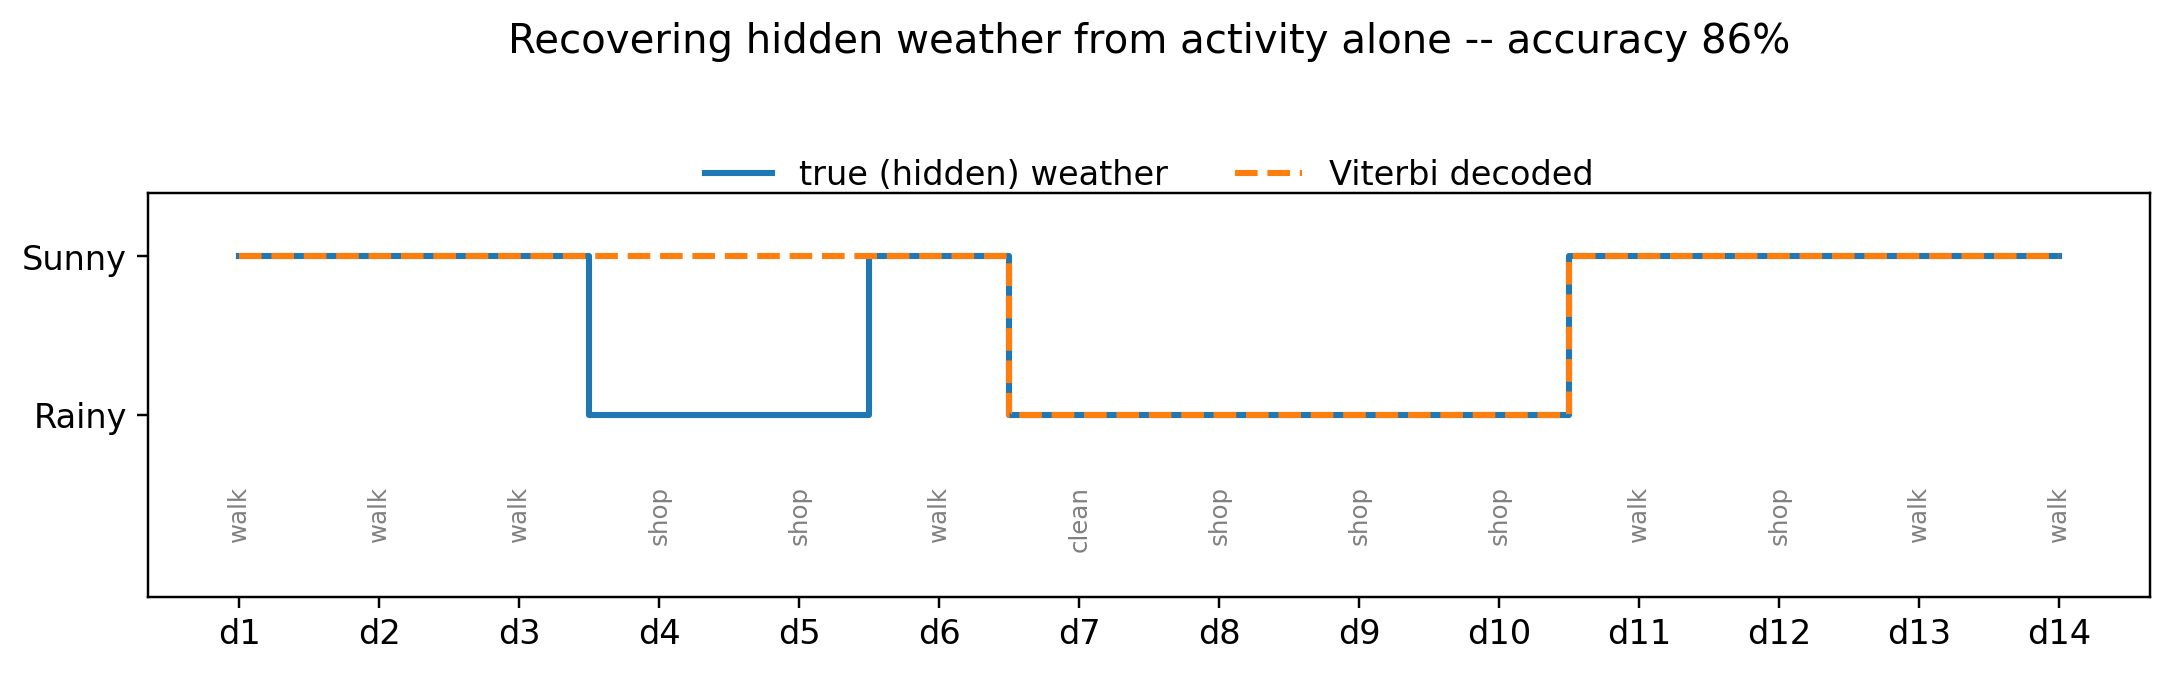

In [11]:
fig, ax = plt.subplots(figsize=(10, 3.2))
t = np.arange(len(obs))
ax.step(t, zs,        where="mid", lw=2,           label="true (hidden) weather")
ax.step(t, path_pyro, where="mid", lw=2, ls="--",  label="Viterbi decoded")
for i in t:
    ax.text(i, -0.45, obs_names[int(obs[i])], rotation=90, ha="center", va="top", fontsize=8, color="gray")
acc = float(np.mean(np.array(zs) == np.array(path_pyro)))
ax.set_yticks([0, 1]); ax.set_yticklabels(states)
ax.set_xticks(t); ax.set_xticklabels([f"d{i+1}" for i in t])
ax.set_ylim(-1.15, 1.4)
ax.set_title(f"Recovering hidden weather from activity alone -- accuracy {acc:.0%}", pad=46)
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.16), frameon=False)
plt.tight_layout(); plt.show()

## Why do it in Pyro?

For a two-state weather model the hand-written forward and Viterbi passes are only a few lines, so Pyro looks like overkill. The payoff is that **the model is just a function, and we can change its graphical structure without touching the inference code**. In the next posts we will:

- **learn** $\pi, A, B$ from data instead of hard-coding them (EM / stochastic variational inference),
- swap the discrete emission for a **Gaussian** one, for continuous observations,
- and stack several chains into a **factorial HMM** -- the natural model for energy disaggregation (NILM), where total power is the sum of several appliances that each switch on and off on their own.

Same `pyro.sample` skeleton, richer graph. That is the whole point of this series.